# OPTIMIZING PROFITABILITY AND DISCOUNT STRATEGY USING RETAIL BUSINESS ANALYTICS DATA

## 📌 Project Overview

This project aims to analyze business performance using three key variables: **Sales, Cost, Profit**.  
The analysis focuses on understanding how revenue is generated, how sales and cost impact profitability, and which areas of the business are most efficient.

By exploring patterns, distributions, and relationships between variables, this project provides insights to support better business decision-making.

## 🎯 Objectives

The main objectives of this analysis are:

- Identify key drivers of profitability
- Evaluate impact of discount and cost on margin
- Validate whether category and region influence profit
- Test multiple strategies through simulation
- Provide data-driven business recommendations

## 📊 Variable Definitions

This analysis focuses on understanding the factors affecting profitability (margin). The key variables used in this analysis are:

🔹 Sales
Total revenue generated from a transaction.  
Calculated as:
> Sales = Unit Price × Quantity

---

🔹 Cost
Total cost incurred for a transaction.  
Represents the expense required to generate the sales.

---

🔹 Profit
Net earnings from a transaction after deducting cost.  
Calculated as:
> Profit = Sales − Cost

---

🔹 Margin
Measure of profitability relative to sales.  
Calculated as:
> Margin = Profit / Sales

Indicates how efficient the transaction is in generating profit.

---

🔹 Discount
Percentage reduction applied to the original price.  
Represents pricing strategy that may impact profitability.

---

🔹 Discount Bin
Categorization of discount levels:
- Low: ≤ 10%
- Medium: 10% – 20%
- High: > 20%

Used to analyze how different discount levels affect margin.

---

🔹 Region
Geographical category of the transaction (North, South, East, West).  
Used to evaluate whether location influences profitability.

## 🔍 Analytical Approach

The analysis is conducted in several stages:

1. **Data Understanding**  
   Reviewing dataset structure, data types, and overall quality  

2. **Data Cleaning**  
   Handling missing values, inconsistencies, and outliers  

3. **Exploratory Data Analysis (EDA)**  
   - Distribution analysis  
   - Outlier detection  
   - Relationship analysis between variables  

4. **Insight Generation**  
   Extracting meaningful business insights from the data

## 💡 Expected Insights

This analysis is expected to reveal:

- Whether higher sales always lead to higher profit, or if margin efficiency plays a more critical role
- Whether product categories and regions significantly influence profitability, or if profit is driven by transaction-level dynamics
- The extent to which discount impacts margin and reduces profitability
- How cost contributes to inefficiency alongside discount
- The effectiveness of different discount strategies in improving profit through simulation
- These insights will help identify opportunities to improve profitability and operational efficiency.

## Import Library

Menyiapkan semua library yang dibutuhkan untuk analisis data.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

## Load Dataset

Memuat dataset yang akan dianalisis

In [2]:
path = "DATASETS.xlsx"
df = pd.read_excel(path)

# 1. Data Understanding (Eksplorasi Awal)

Melihat gambaran umum dataset: jumlah data, tipe data, dan struktur.

In [3]:
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 13 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   Order_ID          10000 non-null    float64       
 1   Customer_ID       10000 non-null    str           
 2   Order_Date        10000 non-null    datetime64[us]
 3   Region            10000 non-null    str           
 4   Product_Category  10000 non-null    str           
 5   Customer_Segment  10000 non-null    str           
 6   Quantity          1048575 non-null  int64         
 7   Unit_Price        1048575 non-null  float64       
 8   Discount_Rate     1048575 non-null  float64       
 9   Revenue           1048575 non-null  float64       
 10  Cost              1048575 non-null  float64       
 11  Profit            1048575 non-null  float64       
 12  Payment_Method    10000 non-null    str           
dtypes: datetime64[us](1), float64(6), int64(1), str(5)
me

(1048575, 13)

# 2. Data Cleaning

Membersihkan data dari missing values, duplikasi, atau data tidak konsisten

In [4]:
# cek missing values
df.isnull().sum()

# hapus data kosong
df = df.dropna()

# cek duplikat
df.duplicated().sum()

np.int64(0)

# 3. Data Transformation

Mengubah format atau membuat kolom baru untuk kebutuhan analisis.

In [5]:
df['Sales'] = df['Unit_Price'] * df['Quantity']

In [6]:
df['Margin'] = df['Profit'] / df['Sales']

# 4. Exploratory Data Analysist

## BAGIAN A - Kondisi Sales, Cost, dan Profit secara Keseluruhan

In [7]:
df[['Sales','Cost','Profit','Margin']].describe()

,Sales,Cost,Profit,Margin
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,1407.710162,776.292180,418.949768,0.297503
std,1138.025509,651.473171,368.418447,0.080098
min,10.470000,5.740000,1.970000,0.142158
25%,461.857500,255.592500,131.785000,0.231422
50%,1096.590000,595.480000,311.395000,0.294543
75%,2098.777500,1141.332500,606.845000,0.357645
max,4999.200000,3911.520000,2292.420000,0.499990


### Histogram Sales vs Cost vs Profit

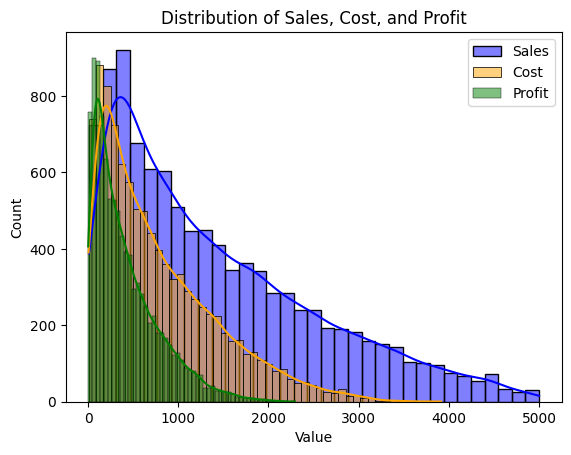

In [8]:
sns.histplot(df['Sales'], color='blue', label='Sales', kde=True)
sns.histplot(df['Cost'], color='orange', label='Cost', kde=True)
sns.histplot(df['Profit'], color='green', label='Profit', kde=True)

plt.legend()
plt.title('Distribution of Sales, Cost, and Profit')
plt.xlabel('Value')
plt.ylabel('Count')

plt.show()

### Sales vs Profit

<Axes: xlabel='Sales', ylabel='Profit'>

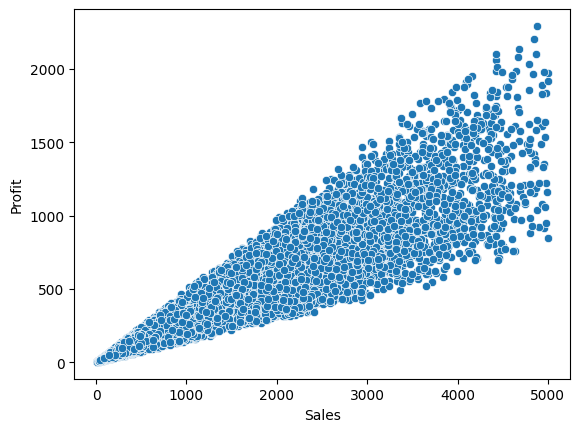

In [9]:
sns.scatterplot(x=df['Sales'], y=df['Profit'])

### Margin

In [10]:
df['Margin'].describe()

count    10000.000000
mean         0.297503
std          0.080098
min          0.142158
25%          0.231422
50%          0.294543
75%          0.357645
max          0.499990
Name: Margin, dtype: float64

### Sales vs Profit berdasarkan Margin

<Axes: xlabel='Sales', ylabel='Profit'>

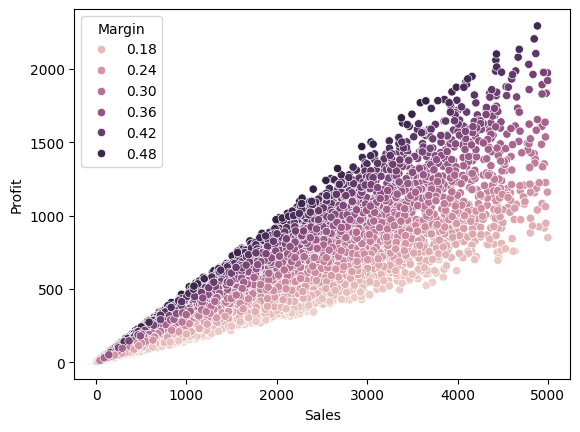

In [11]:
sns.scatterplot(x=df['Sales'], y=df['Profit'], hue=df['Margin'])

### Sales vs Cost

<Axes: xlabel='Sales', ylabel='Cost'>

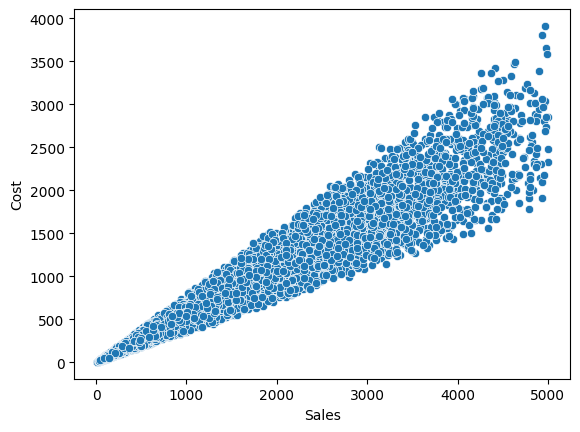

In [12]:
sns.scatterplot(x=df['Sales'], y=df['Cost'])

### A1. Kondisi Sales, Cost, dan Profit Berdasarkan Kategori

In [13]:
sales_category = df.groupby('Product_Category')[['Sales','Cost','Profit']].sum().reset_index()

In [14]:
sales_melt = sales_category.melt(
    id_vars='Product_Category',
    value_vars=['Sales', 'Cost', 'Profit'],
    var_name='Metric',
    value_name='Value'
)

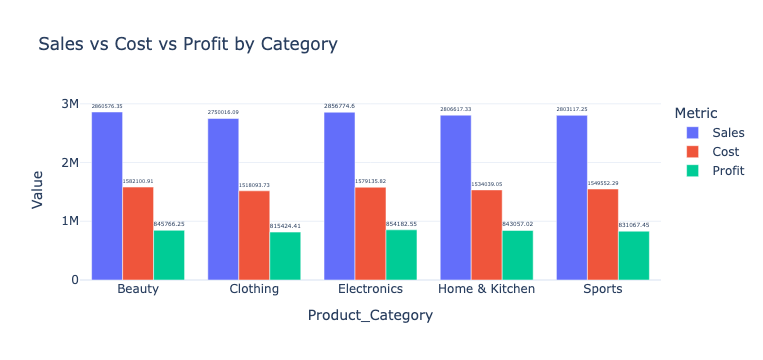

In [15]:
fig = px.bar(
    sales_melt,
    x='Product_Category',
    y='Value',
    color='Metric',
    barmode='group',
    template='plotly_white',
    title='Sales vs Cost vs Profit by Category',
    text='Value'
)

fig.update_traces(textposition='outside')

fig.show()

### Ranking Margin berdasarkan Produk Kategori

In [43]:
df.groupby('Product_Category')['Margin'].agg(['mean', 'std']) \
  .sort_values(by='mean', ascending=False)

,mean,std
Product_Category,,
Electronics,0.298563,0.080322
Sports,0.298020,0.078446
Home & Kitchen,0.297446,0.080588
Beauty,0.296948,0.080577
Clothing,0.296545,0.080595


<Axes: xlabel='Product_Category', ylabel='Margin'>

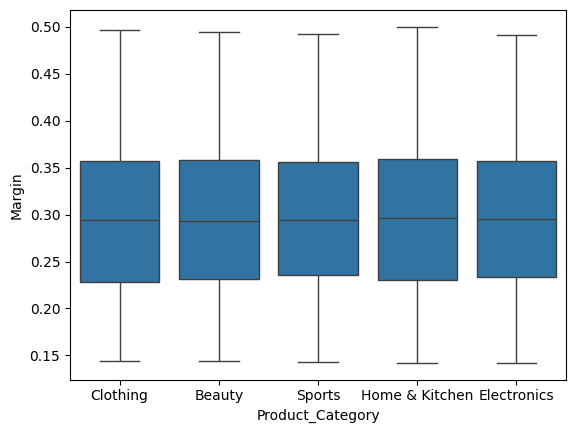

In [18]:
sns.boxplot(x='Product_Category', y='Margin', data=df)

### Discount vs Margin

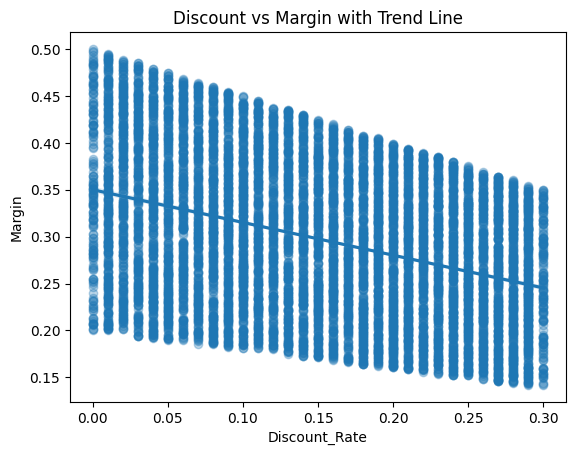

In [19]:
sns.regplot(x=df['Discount_Rate'], y=df['Margin'], scatter_kws={'alpha':0.3})
plt.title('Discount vs Margin with Trend Line')
plt.show()

In [20]:
df['discount_bin'] = pd.cut(
    df['Discount_Rate'],
    bins=[0, 0.1, 0.2, 1],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)
df['discount_bin'].value_counts()

discount_bin
Low       3518
Medium    3301
High      3181
Name: count, dtype: int64

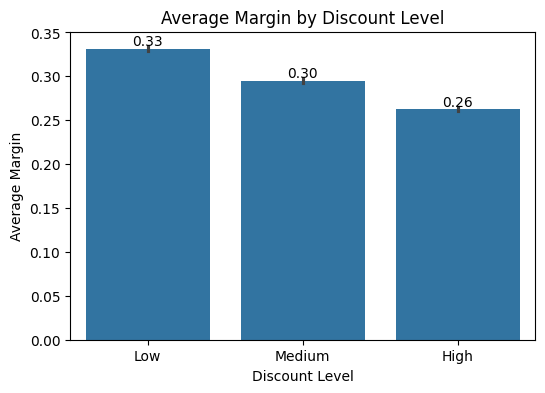

In [21]:
plt.figure(figsize=(6,4))

ax = sns.barplot(
    x='discount_bin',
    y='Margin',
    data=df,
    order=['Low', 'Medium', 'High']
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Average Margin by Discount Level')
plt.xlabel('Discount Level')
plt.ylabel('Average Margin')

plt.show()

### Cost vs Margin

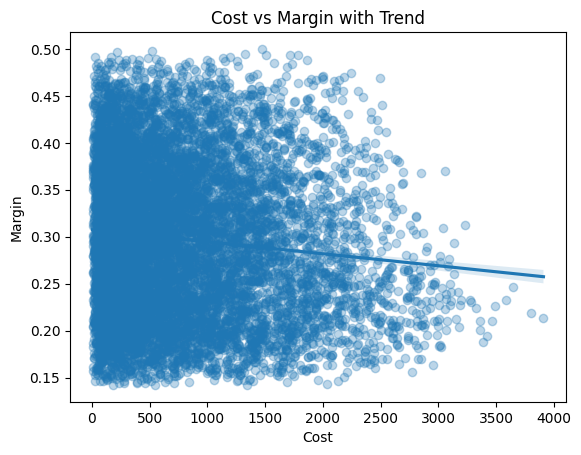

In [22]:
sns.regplot(x=df['Cost'], y=df['Margin'], scatter_kws={'alpha':0.3})
plt.title('Cost vs Margin with Trend')
plt.show()

### Cost vs Margin vs Discount

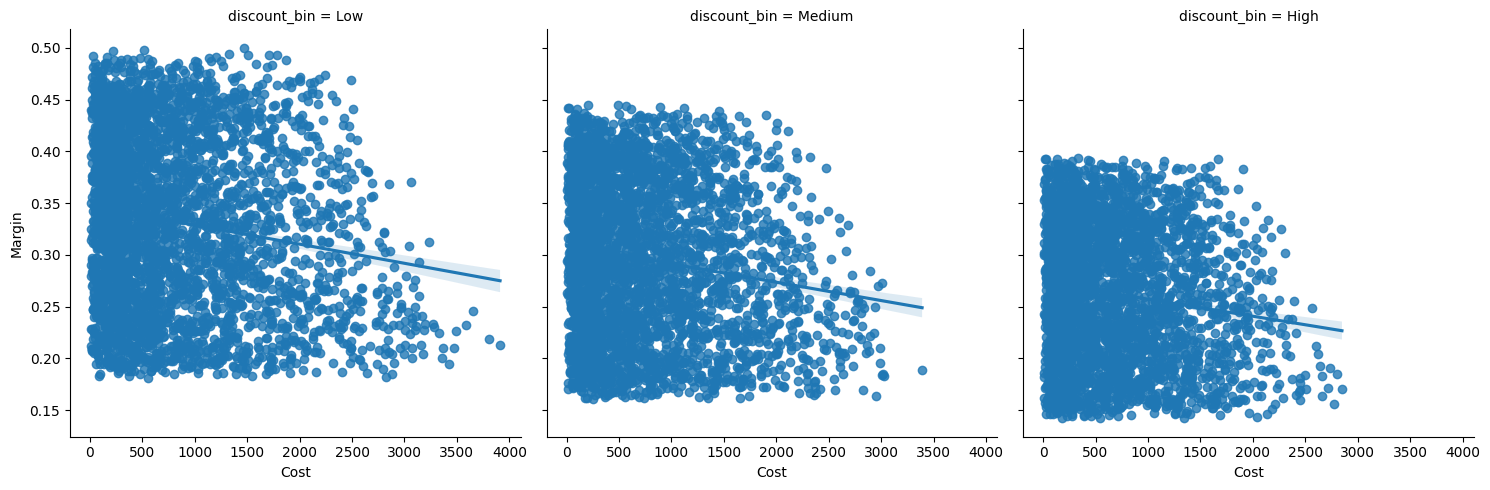

In [23]:
sns.lmplot(
    data=df,
    x='Cost',
    y='Margin',
    col='discount_bin'
)

### Regresi Linear
Uji Regresi Margin terhadap faktor faktor yang kemungkinan mempengaruhi

In [24]:
model = smf.ols(
    'Margin ~ Cost * discount_bin',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Margin   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     339.4
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:48:35   Log-Likelihood:                 11840.
No. Observations:               10000   AIC:                        -2.367e+04
Df Residuals:                    9994   BIC:                        -2.363e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

Kesimpulan :
Kesimpulan pada pengujian regresi linear adalah, faktor diskon medium dan high berpengaruh signifikan serta berefek besar pada margin sedangkan faktor cost berpengaruh signifikan namun berefek kecil pada margin.

The conclusion from the linear regression analysis is that medium and high discount factors have a significant and substantial impact on margin, while cost has a significant but relatively small effect on margin.

### A2. Kondisi Sales, Cost, dan Profit Berdasarkan Region

In [25]:
sales_category = df.groupby('Region')[['Sales','Cost','Profit']].sum().reset_index()

### Margin vs Region

In [26]:
order = df.groupby('Region')['Margin'].mean().sort_values().index

In [27]:
sales_melt = sales_category.melt(
    id_vars='Region',
    value_vars=['Sales', 'Cost', 'Profit'],
    var_name='Metric',
    value_name='Value'
)

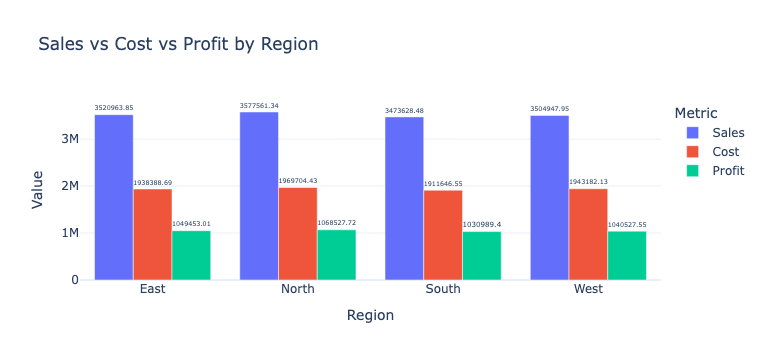

In [28]:
fig = px.bar(
    sales_melt,
    x='Region',
    y='Value',
    color='Metric',
    barmode='group',
    template='plotly_white',
    title='Sales vs Cost vs Profit by Region',
    text='Value'
)

fig.update_traces(textposition='outside')

fig.show()

### Ranking Margin berdasarkan Produk Region

In [29]:
df.groupby('Region')['Margin'].mean().sort_values(ascending=False)

Region
South    0.298335
North    0.297894
East     0.297034
West     0.296750
Name: Margin, dtype: float64

### Regresi Linear
Uji Regresi Margin terhadap faktor faktor yang kemungkinan mempengaruhi

In [30]:
model_region = smf.ols(
    'Margin ~ Region',
    data=df
).fit()

print(model_region.summary())

                            OLS Regression Results                            
Dep. Variable:                 Margin   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2103
Date:                Mon, 30 Mar 2026   Prob (F-statistic):              0.889
Time:                        01:48:35   Log-Likelihood:                 11056.
No. Observations:               10000   AIC:                        -2.210e+04
Df Residuals:                    9996   BIC:                        -2.208e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.2970      0.002    1

### A3. Kesimpulan

Analisis menunjukkan bahwa profitabilitas tidak dipengaruhi oleh kategori produk maupun wilayah, melainkan oleh efisiensi margin pada level transaksi. Faktor utama yang mempengaruhi margin adalah tingkat diskon, dengan kontribusi tambahan dari biaya. Oleh karena itu, optimalisasi profit sebaiknya difokuskan pada pengelolaan strategi diskon dan efisiensi biaya.
Selanjutnya, analisis akan difokuskan pada penyusunan rekomendasi strategi pengelolaan diskon.

The analysis shows that profitability is not influenced by product category or region, but rather by margin efficiency at the transaction level. The main factor affecting margin is the discount level, with additional contribution from cost. Therefore, profit optimization should focus on managing discount strategies and improving cost efficiency.
Next, the analysis will focus on developing recommendations for discount management strategies.

## BAGIAN B - Rekomendasi Bisnis

Rekomendasi berdasarkan data.

### B1. Simulasi

#### Simulasi 1 : membatasi diskon menjadi maksimal 20%

Simulasi 1 yaitu membuat diskon rate diatas 20% menjadi maksimal 20%, dengan asumsi volume penjualan tidak berubah.

In [31]:
# copy data
df_sim = df.copy()

# 1. Batasi discount maksimal 20%
df_sim['discount_adj'] = df_sim['Discount_Rate'].clip(upper=0.2)

# 2. Buat kategori discount baru
df_sim['discount_bin_adj'] = pd.cut(
    df_sim['discount_adj'],
    bins=[0, 0.1, 0.2, 1],
    labels=['Low', 'Medium', 'High']
)

# 3. Mapping margin berdasarkan hasil EDA
margin_map = {
    'Low': 0.33,
    'Medium': 0.30,
    'High': 0.26
}

df_sim['margin_adj'] = df_sim['discount_bin_adj'].map(margin_map).astype(float)

# 4. Hitung ulang profit
df_sim['profit_adj'] = df_sim['Sales'] * df_sim['margin_adj']

# 5. Bandingkan total profit
profit_before = df['Profit'].sum()
profit_after = df_sim['profit_adj'].sum()

impact = profit_after - profit_before
impact_pct = impact / profit_before * 100

print(f"Profit Before : {profit_before:,.0f}")
print(f"Profit After  : {profit_after:,.0f}")
print(f"Impact        : {impact:,.0f} ({impact_pct:.2f}%)")

Profit Before : 4,189,498
Profit After  : 4,293,035
Impact        : 103,537 (2.47%)


#### Simulasi 2 : membatasi diskon tinggi dikurangi 20%

In [32]:
# copy data
df_sim2 = df.copy()

# 1. Kurangi discount 20% untuk yang > 0.2
df_sim2['discount_adj'] = df_sim2['Discount_Rate']

mask = df_sim2['Discount_Rate'] > 0.2
df_sim2.loc[mask, 'discount_adj'] = df_sim2.loc[mask, 'Discount_Rate'] * 0.8

# 2. Buat kategori discount baru
df_sim2['discount_bin_adj'] = pd.cut(
    df_sim2['discount_adj'],
    bins=[0, 0.1, 0.2, 1],
    labels=['Low', 'Medium', 'High']
)

# 3. Mapping margin (berdasarkan hasil EDA kamu)
margin_map = {
    'Low': 0.33,
    'Medium': 0.30,
    'High': 0.26
}

df_sim2['margin_adj'] = df_sim2['discount_bin_adj'].map(margin_map).astype(float)

# 4. Hitung ulang profit
df_sim2['profit_adj'] = df_sim2['Sales'] * df_sim2['margin_adj']

# 5. Bandingkan hasil
profit_before = df['Profit'].sum()
profit_after = df_sim2['profit_adj'].sum()

impact = profit_after - profit_before
impact_pct = impact / profit_before * 100

print(f"Profit Before : {profit_before:,.0f}")
print(f"Profit After  : {profit_after:,.0f}")
print(f"Impact        : {impact:,.0f} ({impact_pct:.2f}%)")

Profit Before : 4,189,498
Profit After  : 4,207,243
Impact        : 17,745 (0.42%)


### Simulasi 3 : Memperbaiki 25% transaksi dengan margin terendah (tidak efisien)

In [33]:
# copy data
df_sim3 = df.copy()

# 1. Tentukan threshold (bottom 25% margin) transaksi terendah
threshold = df_sim3['Margin'].quantile(0.25)

# 2. Buat kolom discount_adj (default = original)
df_sim3['discount_adj'] = df_sim3['Discount_Rate']

# 3. Apply reduction hanya ke transaksi tidak efisien
mask = df_sim3['Margin'] < threshold
df_sim3.loc[mask, 'discount_adj'] = df_sim3.loc[mask, 'Discount_Rate'] * 0.8

# 4. Buat kategori discount baru
df_sim3['discount_bin_adj'] = pd.cut(
    df_sim3['discount_adj'],
    bins=[0, 0.1, 0.2, 1],
    labels=['Low', 'Medium', 'High']
)

# 5. Mapping margin (hasil EDA)
margin_map = {
    'Low': 0.33,
    'Medium': 0.30,
    'High': 0.26
}

df_sim3['margin_adj'] = df_sim3['discount_bin_adj'].map(margin_map).astype(float)

# 6. Hitung ulang profit
df_sim3['profit_adj'] = df_sim3['Sales'] * df_sim3['margin_adj']

# 7. Bandingkan hasil
profit_before = df['Profit'].sum()
profit_after = df_sim3['profit_adj'].sum()

impact = profit_after - profit_before
impact_pct = impact / profit_before * 100

print("=== SIMULATION 3: TARGETED OPTIMIZATION ===")
print(f"Profit Before : {profit_before:,.0f}")
print(f"Profit After  : {profit_after:,.0f}")
print(f"Impact        : {impact:,.0f} ({impact_pct:.2f}%)")

=== SIMULATION 3: TARGETED OPTIMIZATION ===
Profit Before : 4,189,498
Profit After  : 4,149,738
Impact        : -39,760 (-0.95%)


### Simulasi 4 : 

In [34]:
# copy data
df_sim4 = df.copy()

# 1. Tentukan threshold cost tinggi (misal di atas median)
cost_threshold = df_sim4['Cost'].median()

# 2. Buat kolom discount_adj (default = original)
df_sim4['discount_adj'] = df_sim4['Discount_Rate']

# 3. Filter: high discount + high cost
mask = (df_sim4['Discount_Rate'] > 0.2) & (df_sim4['Cost'] > cost_threshold)

# 4. Kurangi discount sebesar 20% hanya untuk target ini
df_sim4.loc[mask, 'discount_adj'] = df_sim4.loc[mask, 'Discount_Rate'] * 0.8

# 5. Buat kategori discount baru
df_sim4['discount_bin_adj'] = pd.cut(
    df_sim4['discount_adj'],
    bins=[0, 0.1, 0.2, 1],
    labels=['Low', 'Medium', 'High']
)

# 6. Mapping margin (hasil EDA)
margin_map = {
    'Low': 0.33,
    'Medium': 0.30,
    'High': 0.26
}

df_sim4['margin_adj'] = df_sim4['discount_bin_adj'].map(margin_map).astype(float)

# 7. Hitung ulang profit
df_sim4['profit_adj'] = df_sim4['Sales'] * df_sim4['margin_adj']

# 8. Bandingkan hasil
profit_before = df['Profit'].sum()
profit_after = df_sim4['profit_adj'].sum()

impact = profit_after - profit_before
impact_pct = impact / profit_before * 100

print("=== SIMULATION 4: SELECTIVE HIGH DISCOUNT CONTROL ===")
print(f"Profit Before : {profit_before:,.0f}")
print(f"Profit After  : {profit_after:,.0f}")
print(f"Impact        : {impact:,.0f} ({impact_pct:.2f}%)")

# 9. (Opsional) Cek jumlah transaksi yang terdampak
print(f"Transactions affected: {mask.sum()}")

=== SIMULATION 4: SELECTIVE HIGH DISCOUNT CONTROL ===
Profit Before : 4,189,498
Profit After  : 4,188,870
Impact        : -627 (-0.01%)
Transactions affected: 1488


### B2. Perbandingan Opsi Simulasi

In [35]:
data = [
    {
        "Scenario": "Sim 1",
        "Strategy": "Cap Discount ≤ 20%",
        "Profit Before": 4189498,
        "Profit After": 4293035,
        "Impact": 103537,
        "Impact (%)": 2.47,
        "Scope": "Semua transaksi",
        "Insight": "Agresif, berpotensi berdampak tinggi",
    },
    {
        "Scenario": "Sim 2",
        "Strategy": "Reduce High Discount 20%",
        "Profit Before": 4189498,
        "Profit After": 4207243,
        "Impact": 17745,
        "Impact (%)": 0.42,
        "Scope": "Hanya diskon tinggi",
        "Insight": "realistis tapi dampak rendah"
    },
    {
        "Scenario": "Sim 3",
        "Strategy": "Target Low Margin",
        "Profit Before": 4189498,
        "Profit After": 4149738,
        "Impact": -39760,
        "Impact (%)": -0.95,
        "Scope": "hanya margin rendah",
        "Insight": "transaksi yang bermasalah"
    },
    {
        "Scenario": "Sim 4",
        "Strategy": "High Discount + High Cost",
        "Profit Before": 4189498,
        "Profit After": 4188870,  
        "Impact": -627,
        "Impact (%)": -0.01,
        "Scope": "Targeted segment",
        "Insight": "paling strategis"
    }
]

summary_df = pd.DataFrame(data)

summary_df["Profit Before"] = summary_df["Profit Before"].apply(lambda x: f"{x:,.0f}" if pd.notnull(x) else "-")
summary_df["Profit After"] = summary_df["Profit After"].apply(lambda x: f"{x:,.0f}" if pd.notnull(x) else "-")
summary_df["Impact"] = summary_df["Impact"].apply(lambda x: f"{x:,.0f}" if pd.notnull(x) else "-")
summary_df["Impact (%)"] = summary_df["Impact (%)"].apply(lambda x: f"{x:.2f}%" if pd.notnull(x) else "-")

summary_df

,Scenario,Strategy,Profit Before,Profit After,Impact,Impact (%),Scope,Insight
0,Sim 1,Cap Discount ≤ 20%,"4,189,498","4,293,035","103,537",2.47%,Semua transaksi,"Agresif, berpotensi berdampak tinggi"
1,Sim 2,Reduce High Discount 20%,"4,189,498","4,207,243","17,745",0.42%,Hanya diskon tinggi,realistis tapi dampak rendah
2,Sim 3,Target Low Margin,"4,189,498","4,149,738","-39,760",-0.95%,hanya margin rendah,transaksi yang bermasalah
3,Sim 4,High Discount + High Cost,"4,189,498","4,188,870",-627,-0.01%,Targeted segment,paling strategis


## BAGIAN C - Kesimpulan dan Rekomendasi